In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 67.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 47.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 1.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=b608dedbc6ba4476ac8d472d4f46176d579c40821eec77d13a674f1a7776cfd1
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


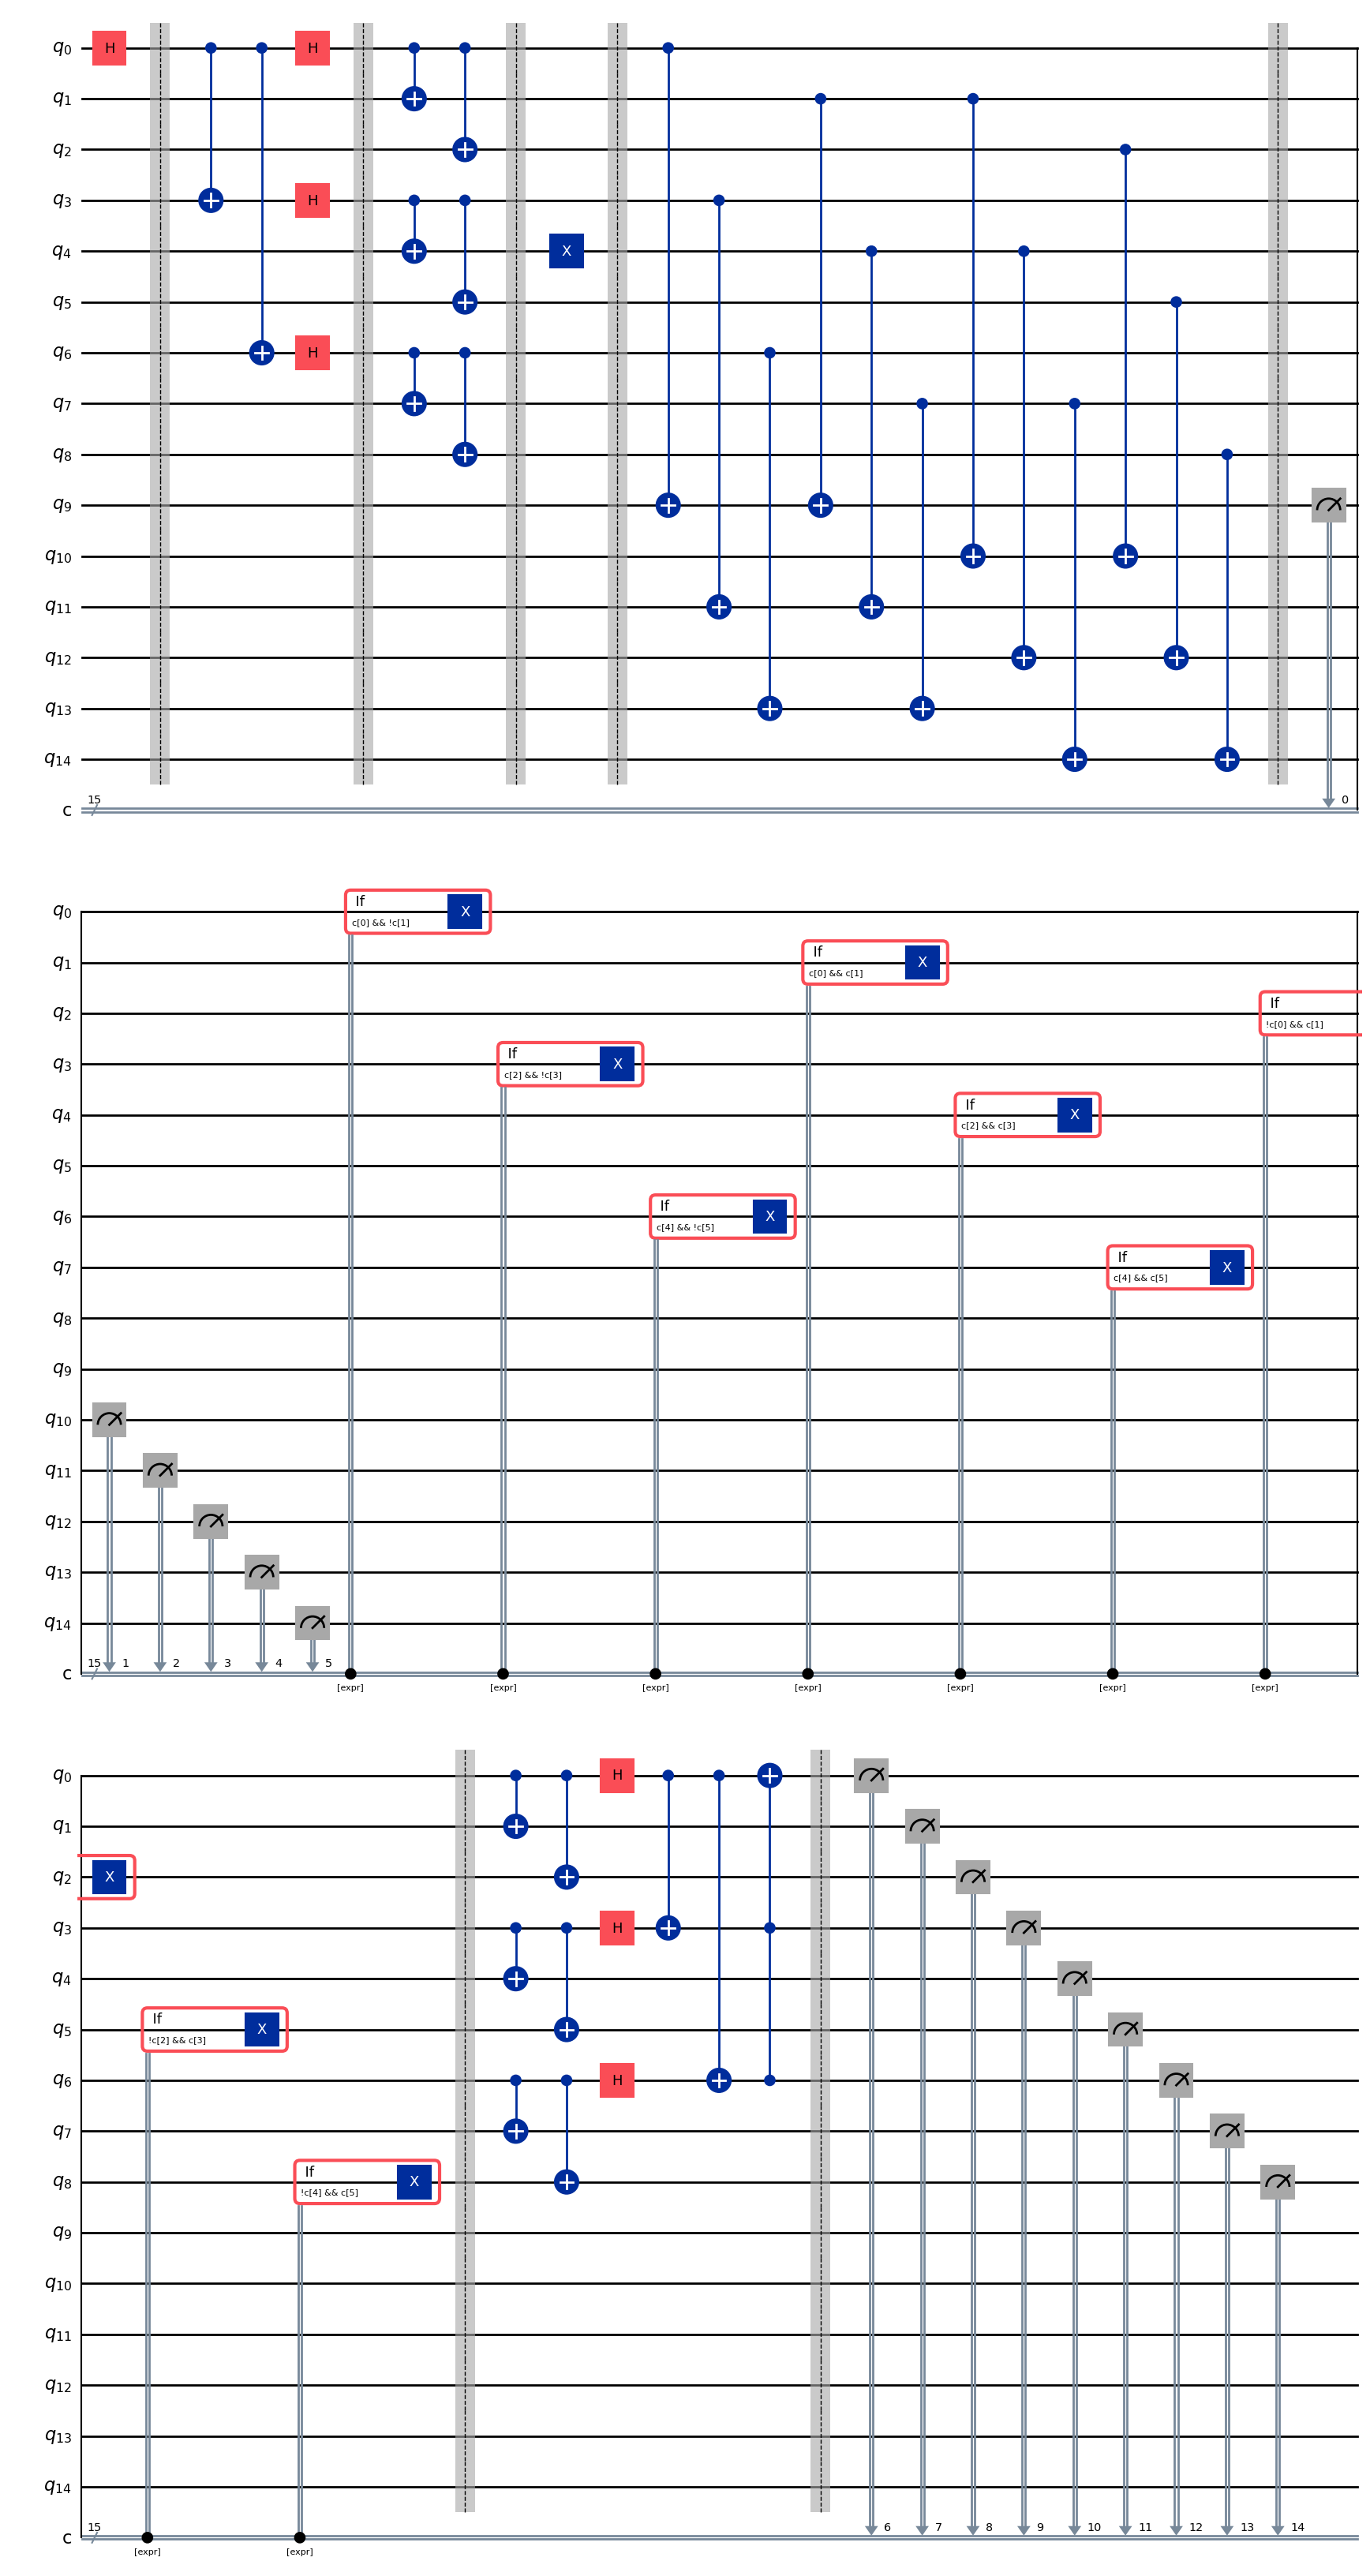

In [6]:
from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts
from qiskit.circuit import ControlledGate
from qiskit.circuit.classical import expr
import math

# Shor code

# Implement the Shor code and experiment with it, checking that it can correct bit-flip and phase-flip errors.
# You can also try applying some other unitary operator as an error, e.g. H.
# You can even construct a unitary operator from a function (as in Lab 3) and apply it as an error.
# You need more qubits now, so you will also have to change the simulation and measurement code in the next cell.

flip = QuantumCircuit(15, 15)

# 1. Prepare logical qubit

flip.h(0)

flip.barrier()

# 2. Phase-flip encoding

flip.cx(0, 3)
flip.cx(0, 6)

flip.h(0)
flip.h(3)
flip.h(6)

flip.barrier()

# 3. Bit-flip encoding inside each block

# block 1
flip.cx(0, 1)
flip.cx(0, 2)

# block 2
flip.cx(3, 4)
flip.cx(3, 5)

# block 3
flip.cx(6, 7)
flip.cx(6, 8)

flip.barrier()

# 4. Introduce errors
# Try:
#
# flip.x(4)    # bit flip
# flip.z(4)    # phase flip
# flip.h(4)    # combined error

flip.x(4)

flip.barrier()

# 5. BIT-FLIP syndrome extraction

# ----- Block 1 -----

flip.cx(0, 9)
flip.cx(1, 9)

flip.cx(1, 10)
flip.cx(2, 10)

# ----- Block 2 -----

flip.cx(3, 11)
flip.cx(4, 11)

flip.cx(4, 12)
flip.cx(5, 12)

# ----- Block 3 -----

flip.cx(6, 13)
flip.cx(7, 13)

flip.cx(7, 14)
flip.cx(8, 14)

flip.barrier()

# 6. Measure syndromes

flip.measure([9,10,11,12,13,14], [0,1,2,3,4,5])

# 7. Conditional bit-flip corrections

# BLOCK 1

# q0 -> syndrome 10

with flip.if_test(
    expr.logic_and(
        flip.clbits[0],
        expr.logic_not(flip.clbits[1])
    )
):
    flip.x(0)

# q1 -> syndrome 11

with flip.if_test(
    expr.logic_and(
        flip.clbits[0],
        flip.clbits[1]
    )
):
    flip.x(1)

# q2 -> syndrome 01

with flip.if_test(
    expr.logic_and(
        expr.logic_not(flip.clbits[0]),
        flip.clbits[1]
    )
):
    flip.x(2)

# BLOCK 2

with flip.if_test(
    expr.logic_and(
        flip.clbits[2],
        expr.logic_not(flip.clbits[3])
    )
):
    flip.x(3)

with flip.if_test(
    expr.logic_and(
        flip.clbits[2],
        flip.clbits[3]
    )
):
    flip.x(4)

with flip.if_test(
    expr.logic_and(
        expr.logic_not(flip.clbits[2]),
        flip.clbits[3]
    )
):
    flip.x(5)

# BLOCK 3

with flip.if_test(
    expr.logic_and(
        flip.clbits[4],
        expr.logic_not(flip.clbits[5])
    )
):
    flip.x(6)

with flip.if_test(
    expr.logic_and(
        flip.clbits[4],
        flip.clbits[5]
    )
):
    flip.x(7)

with flip.if_test(
    expr.logic_and(
        expr.logic_not(flip.clbits[4]),
        flip.clbits[5]
    )
):
    flip.x(8)

flip.barrier()

# 8. Decode phase protection

# Undo repetition encoding

flip.cx(0,1)
flip.cx(0,2)

flip.cx(3,4)
flip.cx(3,5)

flip.cx(6,7)
flip.cx(6,8)

# Convert phase errors into bit errors

flip.h(0)
flip.h(3)
flip.h(6)

# Majority vote phase recovery

flip.cx(0,3)
flip.cx(0,6)

flip.ccx(3,6,0)

flip.barrier()

# 9. Final measurements

flip.measure(range(9), range(6,15))

# Draw circuit

flip.draw("mpl")

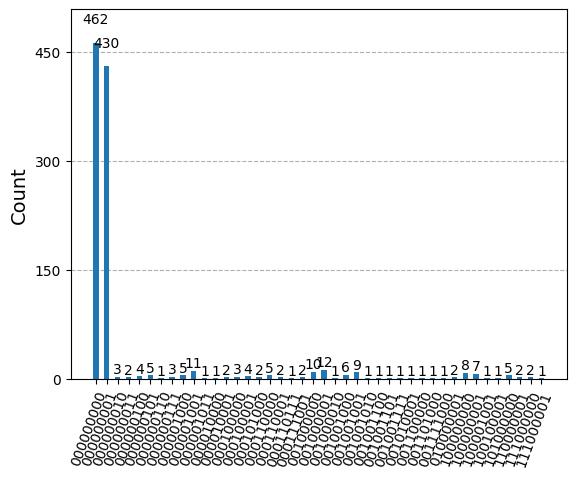

In [8]:
# Simulate and plot results

backend = GenericBackendV2(num_qubits=15, control_flow=True)
compiled = transpile(flip, backend)
job_sim = backend.run(compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(compiled)
mcounts = marginal_counts(counts,indices=[6,7,8,9,10,11,12,13,14])
plot_histogram(mcounts)